In [ ]:
#part 1 and part2
!pip install pandas -q

# Import Library
import pandas as pd

# Load Dataset
df = pd.read_csv("ecommerce_sales.csv")

# Display First 5 Rows
print("First 5 Rows")
display(df.head())

# Dataset Shape
print("Dataset Shape:")
print(df.shape)

# Column Names
print("\nColumn Names:")
print(df.columns)

# Data Types
print("\nData Types:")
print(df.dtypes)

# Missing Values
print("\nMissing Values:")
print(df.isnull().sum())

# Duplicate Records
print("\nDuplicate Records:")
print(df.duplicated().sum())

# Dataset Information
print("\nDataset Information")
df.info()

# Statistical Summary
print("\nStatistical Summary")
display(df.describe())


First 5 Rows


,Order_ID,Customer_Name,Category,Sub_Category,Region,Sales,Quantity,Profit,Order_Date
0,ORD0001,Pam Carlson,Technology,Phones,South,1082.43,3,384.36,2024-10-07
1,ORD0002,Terri Boyd,Furniture,Bookcase,South,3098.77,8,284.04,2025-06-16
2,ORD0003,Maurice Fox,Office Supplies,Binders,East,1603.13,6,130.48,2025-01-16
3,ORD0004,Julie Jenkins,Office Supplies,Binders,North,432.13,1,-204.76,2026-03-06
4,ORD0005,Shawn Miller,Technology,Laptops,East,4036.40,10,94.95,2025-10-15


Dataset Shape:
(1000, 9)

Column Names:
Index(['Order_ID', 'Customer_Name', 'Category', 'Sub_Category', 'Region',
       'Sales', 'Quantity', 'Profit', 'Order_Date'],
      dtype='object')

Data Types:
Order_ID          object
Customer_Name     object
Category          object
Sub_Category      object
Region            object
Sales            float64
Quantity           int64
Profit           float64
Order_Date        object
dtype: object

Missing Values:
Order_ID         0
Customer_Name    0
Category         0
Sub_Category     0
Region           0
Sales            0
Quantity         0
Profit           0
Order_Date       0
dtype: int64

Duplicate Records:
0

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order_ID       1000 non-null   object 
 1   Customer_Name  1000 non-null   object 
 2   Category       1000 non-null 

,Sales,Quantity,Profit
count,1000.00000,1000.000000,1000.000000
mean,2456.11624,5.702000,477.616450
std,1482.05134,2.817647,594.530696
min,51.64000,1.000000,-494.580000
25%,1057.08000,3.000000,-45.785000
50%,2398.59500,6.000000,462.625000
75%,3798.25000,8.000000,988.955000
max,4996.41000,10.000000,1499.720000


In [ ]:


# PART 3 — DATA CLEANING AND PREPROCESSING


import pandas as pd

# Load Dataset
df = pd.read_csv("ecommerce_sales.csv")

# Remove Duplicate Records
df.drop_duplicates(inplace=True)

# Handle Missing Values
for col in df.columns:

    if df[col].dtype == 'object':
        df[col].fillna(df[col].mode()[0], inplace=True)

    else:
        df[col].fillna(df[col].median(), inplace=True)

# Rename Columns
df.columns = [col.lower().replace(" ", "_") for col in df.columns]

# Display Cleaned Data
print("Cleaned Dataset")
display(df.head())

# Check Missing Values Again
print("\nRemaining Missing Values")
print(df.isnull().sum())

# Save Cleaned Dataset
df.to_csv("cleaned_ecommerce_sales.csv", index=False)

print("Cleaned dataset saved successfully.")



Cleaned Dataset


/tmp/ipykernel_523/2851402769.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
/tmp/ipykernel_523/2851402769.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u

,order_id,customer_name,category,sub_category,region,sales,quantity,profit,order_date
0,ORD0001,Pam Carlson,Technology,Phones,South,1082.43,3,384.36,2024-10-07
1,ORD0002,Terri Boyd,Furniture,Bookcase,South,3098.77,8,284.04,2025-06-16
2,ORD0003,Maurice Fox,Office Supplies,Binders,East,1603.13,6,130.48,2025-01-16
3,ORD0004,Julie Jenkins,Office Supplies,Binders,North,432.13,1,-204.76,2026-03-06
4,ORD0005,Shawn Miller,Technology,Laptops,East,4036.40,10,94.95,2025-10-15



Remaining Missing Values
order_id         0
customer_name    0
category         0
sub_category     0
region           0
sales            0
quantity         0
profit           0
order_date       0
dtype: int64
Cleaned dataset saved successfully.


In [ ]:

# PART 4 — SQLITE DATABASE INTEGRATION

import sqlite3
import pandas as pd

# Load Cleaned Dataset
df = pd.read_csv("cleaned_ecommerce_sales.csv")

# Create SQLite Connection
conn = sqlite3.connect("ecommerce_project.db")

# Insert Dataset into Database
df.to_sql(
    "sales_data",
    conn,
    if_exists="replace",
    index=False
)

print("Dataset inserted successfully.")

# Verify Records
query = """
SELECT COUNT(*) AS total_records
FROM sales_data
"""

result = pd.read_sql(query, conn)

display(result)


Dataset inserted successfully.


,total_records
0,1000


In [ ]:

# PART 5 — SQL ANALYSIS

import sqlite3
import pandas as pd

# Connect Database
conn = sqlite3.connect("ecommerce_project.db")

# 1. FILTERING QUERY

query1 = """
SELECT *
FROM sales_data
WHERE sales > 500
"""

result1 = pd.read_sql(query1, conn)

print("Filtering Query")
display(result1.head())

# 2. SORTING QUERY

query2 = """
SELECT *
FROM sales_data
ORDER BY sales DESC
LIMIT 10
"""

result2 = pd.read_sql(query2, conn)

print("Sorting Query")
display(result2)

# 3. AGGREGATION QUERY

query3 = """
SELECT
AVG(sales) AS average_sales,
SUM(sales) AS total_sales,
MAX(sales) AS maximum_sales
FROM sales_data
"""

result3 = pd.read_sql(query3, conn)

print("Aggregation Query")
display(result3)


# 4. GROUP BY QUERY

query4 = """
SELECT
category,
COUNT(*) AS total_orders,
AVG(sales) AS avg_sales
FROM sales_data
GROUP BY category
"""

result4 = pd.read_sql(query4, conn)

print("Group By Query")
display(result4)

# 5. CONDITIONAL QUERY

query5 = """
SELECT
customer_name,
sales,

CASE
    WHEN sales >= 1000 THEN 'High Sales'
    WHEN sales >= 500 THEN 'Medium Sales'
    ELSE 'Low Sales'
END AS sales_category

FROM sales_data
"""

result5 = pd.read_sql(query5, conn)

print("Conditional Query")
display(result5.head())

Filtering Query


,order_id,customer_name,category,sub_category,region,sales,quantity,profit,order_date
0,ORD0001,Pam Carlson,Technology,Phones,South,1082.43,3,384.36,2024-10-07
1,ORD0002,Terri Boyd,Furniture,Bookcase,South,3098.77,8,284.04,2025-06-16
2,ORD0003,Maurice Fox,Office Supplies,Binders,East,1603.13,6,130.48,2025-01-16
3,ORD0005,Shawn Miller,Technology,Laptops,East,4036.40,10,94.95,2025-10-15
4,ORD0006,Daniel Williams,Technology,Phones,North,506.91,9,1189.47,2025-03-23


Sorting Query


,order_id,customer_name,category,sub_category,region,sales,quantity,profit,order_date
0,ORD0328,Mary Lewis,Furniture,Bookcase,South,4996.41,7,-64.72,2025-11-07
1,ORD0437,Sara Roberts,Furniture,Bookcase,North,4995.26,4,1234.61,2026-04-22
2,ORD0578,Dr. Robert Kelly Jr.,Furniture,Chair,South,4991.34,7,-446.00,2025-09-05
3,ORD0577,Sandra Green,Office Supplies,Storage,North,4990.54,4,1271.98,2024-09-30
4,ORD0598,Christopher Davis,Office Supplies,Binders,East,4986.85,4,-101.00,2024-10-26
5,ORD0009,Haley Benson,Office Supplies,Paper,East,4974.53,8,561.94,2026-02-28
6,ORD0465,Joshua Gallagher,Technology,Laptops,North,4965.71,9,-197.81,2024-08-31
7,ORD0626,Tracy Mendez,Technology,Accessories,East,4965.43,4,-430.88,2025-10-07
8,ORD0055,Debra Tucker,Technology,Laptops,West,4965.31,4,-316.38,2025-07-08
9,ORD0555,Joseph Sanchez,Technology,Accessories,South,4957.06,4,-86.10,2026-01-14


Aggregation Query


,average_sales,total_sales,maximum_sales
0,2456.11624,2456116.24,4996.41


Group By Query


,category,total_orders,avg_sales
0,Furniture,329,2501.872006
1,Office Supplies,348,2368.702184
2,Technology,323,2503.690372


Conditional Query


,customer_name,sales,sales_category
0,Pam Carlson,1082.43,High Sales
1,Terri Boyd,3098.77,High Sales
2,Maurice Fox,1603.13,High Sales
3,Julie Jenkins,432.13,Low Sales
4,Shawn Miller,4036.40,High Sales


In [ ]:

# PART 6 — SQL-BASED DATA TRANSFORMATION

import sqlite3
import pandas as pd

# Connect Database
conn = sqlite3.connect("ecommerce_project.db")

# SQL Transformation Query
query_transform = """

SELECT *,

CASE
    WHEN sales >= 1000 THEN 'Premium'
    ELSE 'Regular'
END AS customer_type,

CASE
    WHEN profit > 0 THEN 'Profit'
    ELSE 'Loss'
END AS profit_status

FROM sales_data

"""

# Execute Query
transformed_df = pd.read_sql(query_transform, conn)

# Display Output
display(transformed_df.head())

# Export to CSV
transformed_df.to_csv(
    "transformed_sales_data.csv",
    index=False
)

print("Transformed dataset exported successfully.")

,order_id,customer_name,category,sub_category,region,sales,quantity,profit,order_date,customer_type,profit_status
0,ORD0001,Pam Carlson,Technology,Phones,South,1082.43,3,384.36,2024-10-07,Premium,Profit
1,ORD0002,Terri Boyd,Furniture,Bookcase,South,3098.77,8,284.04,2025-06-16,Premium,Profit
2,ORD0003,Maurice Fox,Office Supplies,Binders,East,1603.13,6,130.48,2025-01-16,Premium,Profit
3,ORD0004,Julie Jenkins,Office Supplies,Binders,North,432.13,1,-204.76,2026-03-06,Regular,Loss
4,ORD0005,Shawn Miller,Technology,Laptops,East,4036.40,10,94.95,2025-10-15,Premium,Profit


Transformed dataset exported successfully.


In [ ]:
# PART 7 — ETL PIPELINE

import pandas as pd

# EXTRACT

print("EXTRACT STAGE")

extract_df = pd.read_csv("ecommerce_sales.csv")

display(extract_df.head())

# TRANSFORM

print("TRANSFORM STAGE")

# Remove Duplicates
extract_df.drop_duplicates(inplace=True)

# Handle Missing Values
for col in extract_df.columns:

    if extract_df[col].dtype == 'object':
        extract_df[col].fillna(
            extract_df[col].mode()[0],
            inplace=True
        )

    else:
        extract_df[col].fillna(
            extract_df[col].median(),
            inplace=True
        )

display(extract_df.head())


print("LOAD STAGE")

extract_df.to_csv(
    "etl_output.csv",
    index=False
)

print("ETL Pipeline Completed Successfully.")

EXTRACT STAGE


,Order_ID,Customer_Name,Category,Sub_Category,Region,Sales,Quantity,Profit,Order_Date
0,ORD0001,Pam Carlson,Technology,Phones,South,1082.43,3,384.36,2024-10-07
1,ORD0002,Terri Boyd,Furniture,Bookcase,South,3098.77,8,284.04,2025-06-16
2,ORD0003,Maurice Fox,Office Supplies,Binders,East,1603.13,6,130.48,2025-01-16
3,ORD0004,Julie Jenkins,Office Supplies,Binders,North,432.13,1,-204.76,2026-03-06
4,ORD0005,Shawn Miller,Technology,Laptops,East,4036.40,10,94.95,2025-10-15


TRANSFORM STAGE


/tmp/ipykernel_523/2057272103.py:30: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  extract_df[col].fillna(
/tmp/ipykernel_523/2057272103.py:36: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: va

,Order_ID,Customer_Name,Category,Sub_Category,Region,Sales,Quantity,Profit,Order_Date
0,ORD0001,Pam Carlson,Technology,Phones,South,1082.43,3,384.36,2024-10-07
1,ORD0002,Terri Boyd,Furniture,Bookcase,South,3098.77,8,284.04,2025-06-16
2,ORD0003,Maurice Fox,Office Supplies,Binders,East,1603.13,6,130.48,2025-01-16
3,ORD0004,Julie Jenkins,Office Supplies,Binders,North,432.13,1,-204.76,2026-03-06
4,ORD0005,Shawn Miller,Technology,Laptops,East,4036.40,10,94.95,2025-10-15


LOAD STAGE
ETL Pipeline Completed Successfully.


In [ ]:
#PART 8
# Install PySpark
!pip install pyspark -q

# Import Libraries
from pyspark.sql import SparkSession
from pyspark.sql.functions import *

# Create Spark Session
spark = SparkSession.builder \
    .appName("MedallionArchitecture") \
    .getOrCreate()
# BRONZE LAYER
bronze_df = spark.read.csv(
    "ecommerce_sales.csv",
    header=True,
    inferSchema=True
)
bronze_df.write.mode("overwrite") \
    .parquet("bronze_layer")
print("Bronze Layer Created")

# SILVER LAYER
silver_df = bronze_df.dropDuplicates()
silver_df = silver_df.na.drop()
silver_df.write.mode("overwrite") \
    .parquet("silver_layer")
print("Silver Layer Created")

# GOLD LAYER
gold_df = silver_df.groupBy("category").agg(
    avg("sales").alias("avg_sales"),
    sum("profit").alias("total_profit"),
    count("*").alias("total_orders")
)
gold_df.write.mode("overwrite") \
    .parquet("gold_layer")
print("Gold Layer Created")
gold_df.show()

Bronze Layer Created
Silver Layer Created
Gold Layer Created
+---------------+------------------+------------------+------------+
|       category|         avg_sales|      total_profit|total_orders|
+---------------+------------------+------------------+------------+
|Office Supplies|2368.7021839080458|181174.72999999995|         348|
|      Furniture| 2501.872006079028|145517.27999999988|         329|
|     Technology|  2503.69037151703|150924.43999999997|         323|
+---------------+------------------+------------------+------------+



In [ ]:

# PART 9 — CSV VS PARQUET COMPARISON

import pandas as pd

comparison = pd.DataFrame({
    "Feature": [
        "File Size",
        "Storage Efficiency",
        "Read Performance",
        "Write Performance",
        "Advantages",
        "Limitations"
    ],
    "CSV": [
        "Large",
        "Low",
        "Slow",
        "Slow",
        "Human Readable",
        "No Compression"
    ],
    "PARQUET": [
        "Small",
        "High",
        "Fast",
        "Fast",
        "Compressed & Optimized",
        "Not Human Readable"
    ]
})

display(comparison)

,Feature,CSV,PARQUET
0,File Size,Large,Small
1,Storage Efficiency,Low,High
2,Read Performance,Slow,Fast
3,Write Performance,Slow,Fast
4,Advantages,Human Readable,Compressed & Optimized
5,Limitations,No Compression,Not Human Readable


In [ ]:
# PART 10 — PARQUET TO PANDAS CONVERSION

from pyspark.sql import SparkSession

# Create Spark Session
spark = SparkSession.builder \
    .appName("ParquetToPandas") \
    .getOrCreate()

# Read Parquet File
parquet_df = spark.read.parquet("gold_layer")

# Show Data
print("Parquet DataFrame (first 20 rows):")
parquet_df.show()

# Convert to Pandas DataFrame
pandas_df = parquet_df.toPandas()
print("\nConverted Pandas DataFrame (first 5 rows):")
display(pandas_df.head())

Parquet DataFrame (first 20 rows):
+---------------+------------------+------------------+------------+
|       category|         avg_sales|      total_profit|total_orders|
+---------------+------------------+------------------+------------+
|Office Supplies|2368.7021839080458|181174.72999999995|         348|
|      Furniture| 2501.872006079028|145517.27999999988|         329|
|     Technology|  2503.69037151703|150924.43999999997|         323|
+---------------+------------------+------------------+------------+


Converted Pandas DataFrame (first 5 rows):


,category,avg_sales,total_profit,total_orders
0,Office Supplies,2368.702184,181174.73,348
1,Furniture,2501.872006,145517.28,329
2,Technology,2503.690372,150924.44,323


Neither 'cleaned_ecommerce_sales.csv' nor 'ecommerce_sales.csv' found. Loading fallback dataset '/content/sample_data/california_housing_train.csv'...
Using fallback data. Visualizations will reflect this dataset.


/tmp/ipykernel_2919/3723905386.py:65: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("category")["sales"].sum().plot(


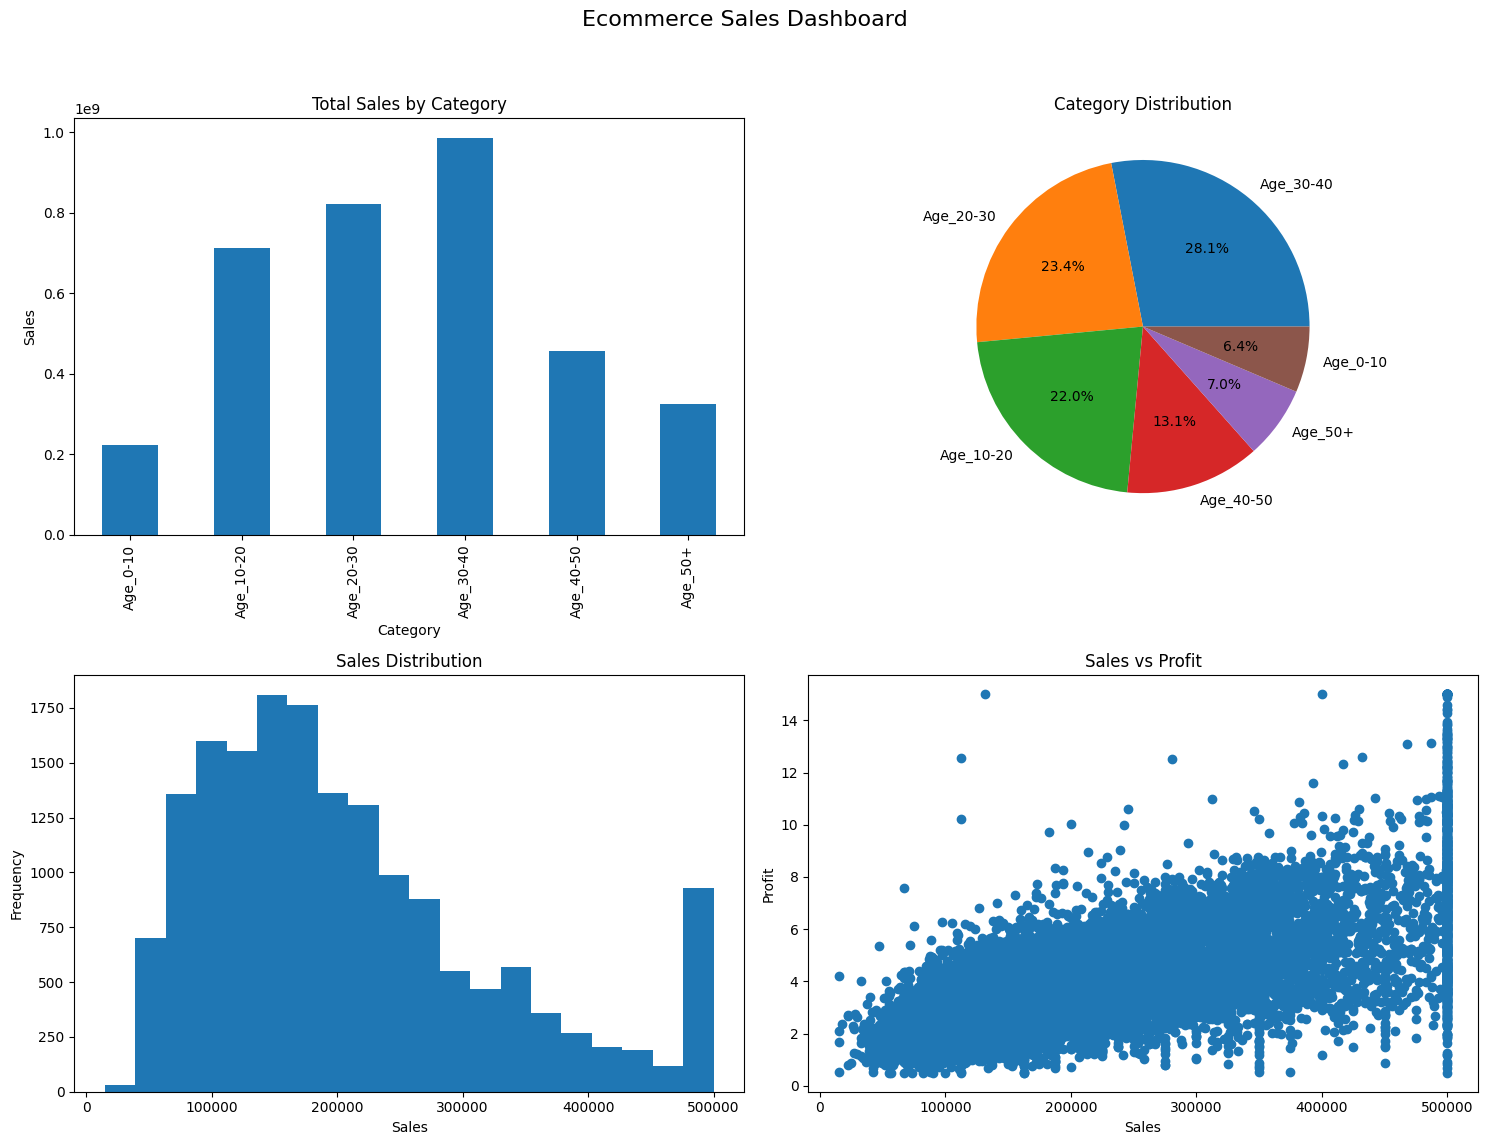

In [4]:
# PART 11 — DATA VISUALIZATION


import pandas as pd
import matplotlib.pyplot as plt
import os

# Define file paths
cleaned_file = "cleaned_ecommerce_sales.csv"
original_file = "ecommerce_sales.csv"
fallback_file = "/content/sample_data/california_housing_train.csv"

# Load Dataset
if os.path.exists(cleaned_file):
    print(f"Loading {cleaned_file}...")
    df = pd.read_csv(cleaned_file)
elif os.path.exists(original_file):
    print(f"'{cleaned_file}' not found. Loading and cleaning '{original_file}'...")
    df = pd.read_csv(original_file)

    # Remove Duplicate Records
    df.drop_duplicates(inplace=True)

    # Handle Missing Values
    for col in df.columns:
        if df[col].dtype == 'object':
            df[col].fillna(df[col].mode()[0], inplace=True)
        else:
            df[col].fillna(df[col].median(), inplace=True)

    # Rename Columns to consistent lower_snake_case for plotting
    df.columns = [col.lower().replace(" ", "_") for col in df.columns]

    # Optionally save the cleaned dataset for future use
    df.to_csv(cleaned_file, index=False)
    print(f"'{cleaned_file}' created and loaded.")
else:
    print(f"Neither '{cleaned_file}' nor '{original_file}' found. Loading fallback dataset '{fallback_file}'...")
    # Load a fallback dataset if original is missing to ensure code runs
    try:
        df = pd.read_csv(fallback_file)
        # Adapt fallback data to match expected columns for visualization
        df = df.rename(columns={
            'median_house_value': 'sales',
            'median_income': 'profit',
            'housing_median_age': 'category_raw' # temporary column for category creation
        })
        # Create a simple category from 'category_raw'
        df['category'] = pd.cut(df['category_raw'], bins=[0, 10, 20, 30, 40, 50, 60], labels=['Age_0-10', 'Age_10-20', 'Age_20-30', 'Age_30-40', 'Age_40-50', 'Age_50+'], right=False)
        df.drop(columns=['category_raw'], inplace=True) # drop the raw column after categorization
        print("Using fallback data. Visualizations will reflect this dataset.")
    except FileNotFoundError:
        print(f"Fallback file '{fallback_file}' also not found. Cannot generate dashboard without data.")
        df = pd.DataFrame() # Create empty DataFrame to prevent further errors


# Ensure DataFrame is not empty before attempting to plot
if not df.empty:
    # Create a figure and a 2x2 grid of subplots
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Ecommerce Sales Dashboard', fontsize=16)

    # 1. BAR CHART (Category by Sales)
    if 'category' in df.columns and 'sales' in df.columns:
        df.groupby("category")["sales"].sum().plot(
            kind="bar", ax=axes[0, 0]
        )
        axes[0, 0].set_title("Total Sales by Category")
        axes[0, 0].set_xlabel("Category")
        axes[0, 0].set_ylabel("Sales")
    else:
        axes[0, 0].set_title("Missing 'category' or 'sales' for Bar Chart")

    # 2. PIE CHART (Category Distribution)
    if 'category' in df.columns:
        df["category"].value_counts().plot(
            kind="pie",
            autopct="%1.1f%%",
            ax=axes[0, 1]
        )
        axes[0, 1].set_title("Category Distribution")
        axes[0, 1].set_ylabel("")
    else:
        axes[0, 1].set_title("Missing 'category' for Pie Chart")

    # 3. HISTOGRAM (Sales Distribution)
    if 'sales' in df.columns:
        axes[1, 0].hist(df["sales"], bins=20)
        axes[1, 0].set_title("Sales Distribution")
        axes[1, 0].set_xlabel("Sales")
        axes[1, 0].set_ylabel("Frequency")
    else:
        axes[1, 0].set_title("Missing 'sales' for Histogram")

    # 4. SCATTER PLOT (Sales vs Profit)
    if 'sales' in df.columns and 'profit' in df.columns:
        axes[1, 1].scatter(
            df["sales"],
            df["profit"]
        )
        axes[1, 1].set_title("Sales vs Profit")
        axes[1, 1].set_xlabel("Sales")
        axes[1, 1].set_ylabel("Profit")
    else:
        axes[1, 1].set_title("Missing 'sales' or 'profit' for Scatter Plot")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
    plt.show()
else:
    print("Dashboard cannot be generated as no data was loaded.")

In [ ]:
# PART 12 — MACHINE LEARNING MODEL

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Load Dataset
df = pd.read_csv("transformed_sales_data.csv")

# Encode Categorical Columns
encoder = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = encoder.fit_transform(df[col])

# Features and Target
X = df.drop("customer_type", axis=1)
y = df["customer_type"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Create Model
model = RandomForestClassifier()

# Train Model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Classification Report
print("\nClassification Report")
print(classification_report(y_test, y_pred))

# Confusion Matrix
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

Accuracy: 1.0

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       161
           1       1.00      1.00      1.00        39

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200


Confusion Matrix
[[161   0]
 [  0  39]]
